These are the updated empirical results for the paper, for the meeting on 18 May
2026. The main change since the previous version is that every example now
includes Gaussian-NPE alongside flow-NPE.

The paper asks one question. How large must the simulation budget $N$ be,
relative to the number of observations $n$ and the problem dimension $d$ (the
number of summaries plus the number of parameters), for NPE to recover the
posterior. The theory answers this in two regimes. In the general case, where
the posterior is only assumed smooth, the required budget grows with $d$ in the
exponent and is far too large to be practical. In the nice case, where the
posterior is close to Gaussian for large $n$ (a Bernstein-von Mises regime), the
requirement drops to $N \gg d^2 n$. This second regime is the practical one, and
the $d^2 n$ scaling is the headline.

Two methods are compared against a reference posterior across the budget grid
$N \in \{n,\ n\log n,\ n^{3/2},\ n^2\}$. flow-NPE uses a normalising flow, the
flexible family used throughout the paper. Gaussian-NPE uses a conditional
Gaussian, where a network outputs the posterior mean and covariance. Gaussian-NPE
is the nice case made concrete, since the Bernstein-von Mises result only needs
the approximating family to contain Gaussians. So the question is not which
method wins, it is whether the simpler Gaussian-NPE is enough once the target
posterior is close to Gaussian.

All results use simulated data, so the true parameters are known by
construction. Coverage is computed by Monte Carlo over 100 simulated datasets,
and the posterior overlays are single simulated datasets. A few of the largest
cells are still filling in, or for the stereological example not feasible to
run, and these are flagged where they appear.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.5,
})
C_FLOW, C_GAUSS, C_REF = "#1f77b4", "#d62728", "#444444"
C_DELTA1, C_TIMEOUT = "#2ca02c", "#7f7f7f"
BUDGETS = ["N=n", "N=n log(n)", "N=n^(3/2)", "N=n^2"]
BUDGET_MATH = ["n", r"n\log n", r"n^{3/2}", r"n^2"]
N_OBS = [100, 500, 1000, 5000]
METHOD_NAME = {"flow_npe": "flow-NPE", "gaussian_npe": "Gaussian-NPE"}
GNK_TRUE = {"A": 3.0, "B": 1.0, "g": 2.0, "k": 0.5}
PARAM_MATH = {"A": "A", "B": "B", "g": "g", "k": "k",
              "lambda": r"\lambda", "sigma": r"\sigma", "xi": r"\xi"}

# Stereological

The stereological model has three parameters $(\lambda, \sigma, \xi)$ and four
summaries, so $d = 7$, and it is the paper's motivating example. There is no
analytic posterior, so SMC-ABC is used as a benchmark. With the dimension this
low the budget the theory asks for is modest, and the results below show that
$N$ at or above $n^{3/2}$ is already enough for good coverage. We report
coverage, posterior bias, and a posterior overlay.

**Coverage.** Monte Carlo coverage of the 95% credible intervals, computed over
100 simulated datasets and averaged over the three parameters. Each dataset has
known true parameters by construction, and coverage counts how often the
interval contains the true value. Near or above the nominal 0.95 is good. The
$n=5000,\ N=n^2$ cell is not run, its simulation cost is very large, so it is
left blank.

In [2]:
cov = pd.read_csv(DATA / "stereological_coverage.csv")
cov = cov[cov.N_label.isin(BUDGETS)].copy()
cov["method"] = cov["method"].map(METHOD_NAME)
cov_avg = (cov.groupby(["method", "N_label", "n"])["coverage_95_mean"]
              .mean().reset_index())
cov_avg["N_label"] = pd.Categorical(cov_avg["N_label"], categories=BUDGETS,
                                    ordered=True)
cov_table = cov_avg.pivot_table(index=["method", "N_label"], columns="n",
                                values="coverage_95_mean", observed=True)
cov_table = cov_table.sort_index()[N_OBS].round(3)
cov_table = cov_table.where(cov_table.notna(), "")
cov_table.index.names = ["method", "budget"]
cov_table.columns.name = "n"
cov_table

n                         100    500    1000   5000
method       budget                                
Gaussian-NPE N=n         0.996  0.999  0.987  0.997
             N=n log(n)  0.992  0.975  0.981  0.989
             N=n^(3/2)   0.973  0.982  0.987  0.992
             N=n^2       0.986  0.975  0.983       
flow-NPE     N=n         0.929  0.986  0.997  0.999
             N=n log(n)  0.984  0.993  0.994  0.992
             N=n^(3/2)   0.992  0.986  0.982  0.974
             N=n^2       0.983  0.965  0.965

**Posterior-mean bias.** Boxplots of the per-seed posterior-mean bias, by
parameter (rows) and observation count (columns), with flow-NPE and
Gaussian-NPE side by side at each budget. The dashed line is zero bias.

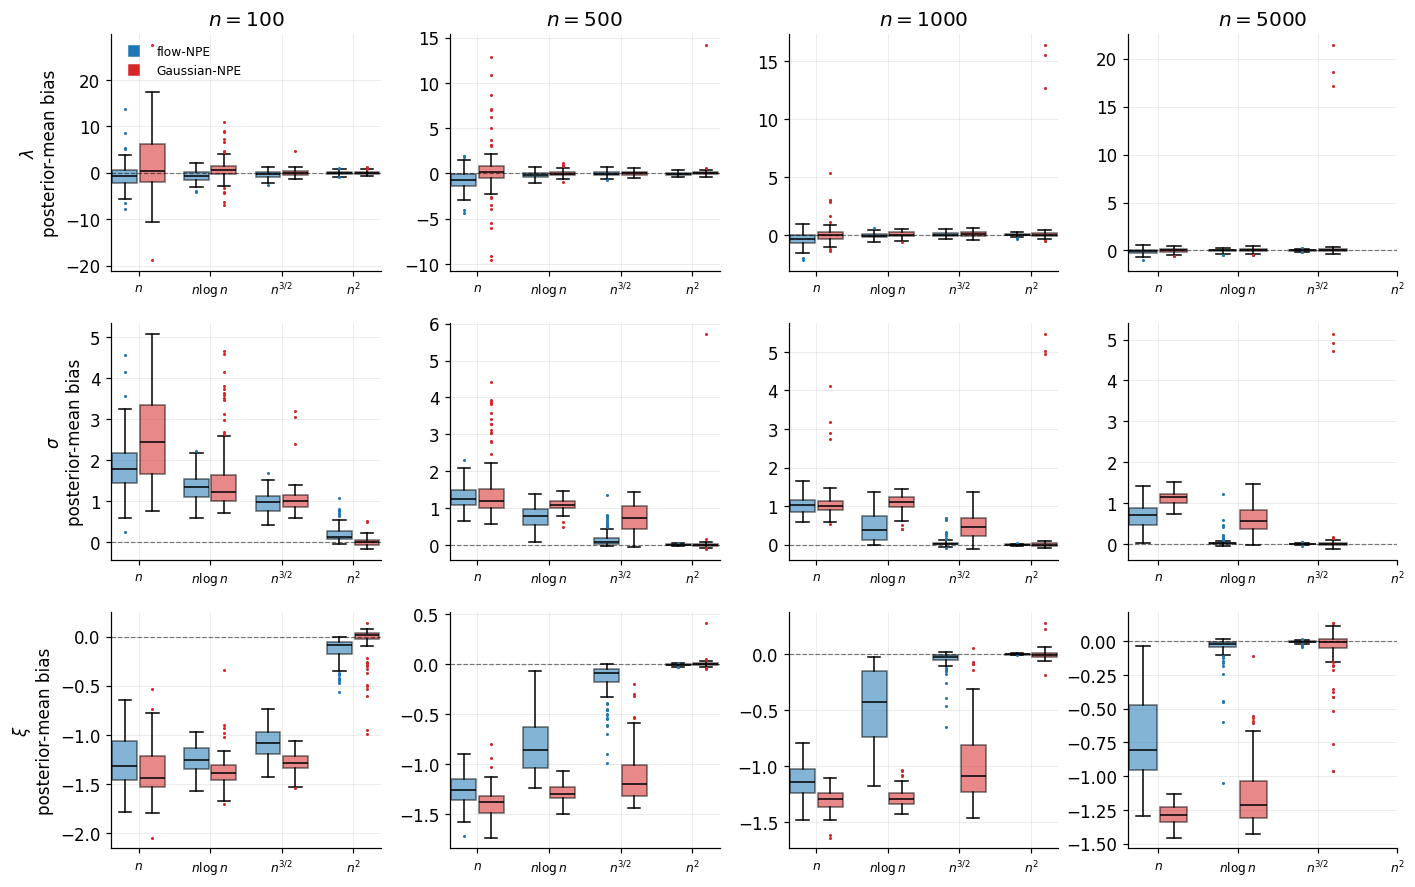

In [3]:
bias = pd.read_csv(DATA / "stereological_bias_by_seed.csv")
bias = bias[bias.N_label.isin(BUDGETS)]
params = ["lambda", "sigma", "xi"]
fig, axes = plt.subplots(3, 4, figsize=(13, 8.2))
for r, param in enumerate(params):
    for c, n in enumerate(N_OBS):
        ax = axes[r, c]
        for b, bud in enumerate(BUDGETS):
            for k, (raw, color) in enumerate([("flow_npe", C_FLOW),
                                              ("gaussian_npe", C_GAUSS)]):
                vals = bias[(bias["param"] == param) & (bias.n == n)
                            & (bias.N_label == bud)
                            & (bias.method == raw)]["mean_bias"].dropna().values
                if len(vals) == 0:
                    continue
                bp = ax.boxplot([vals], positions=[b * 2.6 + k], widths=0.9,
                                patch_artist=True,
                                flierprops=dict(marker=".", markersize=2,
                                                markerfacecolor=color,
                                                markeredgecolor=color))
                for patch in bp["boxes"]:
                    patch.set_facecolor(color)
                    patch.set_alpha(0.55)
                for med in bp["medians"]:
                    med.set_color("black")
        ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_xticks([b * 2.6 + 0.5 for b in range(4)])
        ax.set_xticklabels([f"${b}$" for b in BUDGET_MATH], fontsize=8)
        if r == 0:
            ax.set_title(f"$n = {n}$")
        if c == 0:
            ax.set_ylabel(f"${PARAM_MATH[param]}$\nposterior-mean bias")
axes[0, 0].plot([], [], "s", color=C_FLOW, label="flow-NPE")
axes[0, 0].plot([], [], "s", color=C_GAUSS, label="Gaussian-NPE")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

**Posterior overlay for $\lambda$** (a single simulated dataset, $n=1000$, seed
1). This matches the main stereological figure in the paper, the NPE posterior
at each budget $N$ against the SMC-ABC benchmark, for each method. The dashed
line is the true $\lambda$. The overlay is shown for $\lambda$ only, the single
local SMC-ABC run converged poorly on $\sigma$ and $\xi$, so extending it to all
three parameters needs a longer SMC-ABC run, which is on the list of remaining
items.

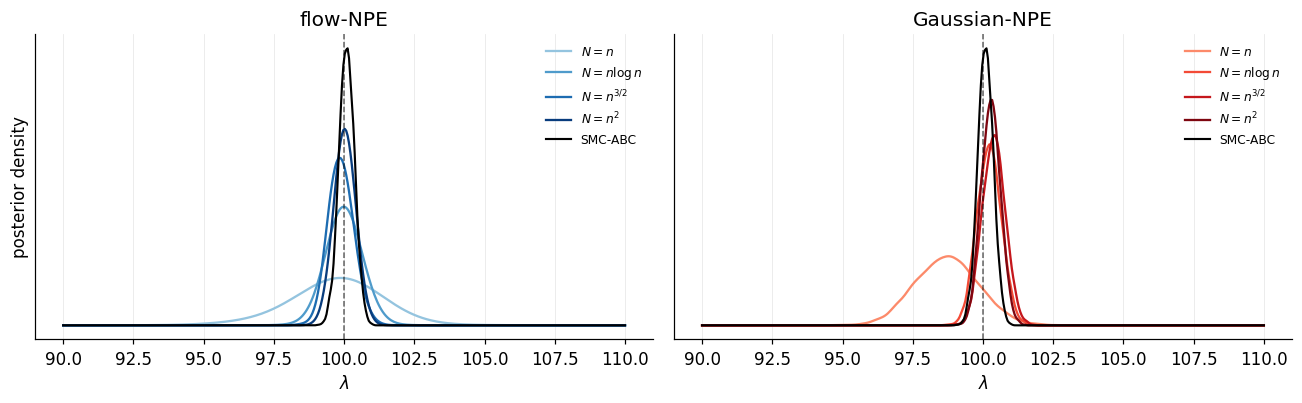

In [4]:
ster_ov = pd.read_csv(DATA / "stereological_posterior_overlay.csv")
lam = ster_ov[ster_ov.param == "lambda"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
specs = [("flow_npe", "flow-NPE", plt.cm.Blues),
         ("gaussian_npe", "Gaussian-NPE", plt.cm.Reds)]
for ax, (raw, mname, cmap) in zip(axes, specs):
    shades = cmap(np.linspace(0.4, 0.95, len(BUDGETS)))
    for bud, shade, lab in zip(BUDGETS, shades, BUDGET_MATH):
        s = lam[(lam.method == raw) & (lam.N_label == bud)].sort_values("x")
        ax.plot(s.x, s.density, color=shade, label=f"$N={lab}$")
    a = lam[lam.method == "abc_smc"].sort_values("x")
    ax.plot(a.x, a.density, color="black", lw=1.4, label="SMC-ABC")
    ax.axvline(100.0, color="black", ls="--", lw=1, alpha=0.6)
    ax.set_title(mname)
    ax.set_xlabel(r"$\lambda$")
    ax.set_yticks([])
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("posterior density")
fig.tight_layout()
plt.show()

Coverage is near or above the nominal level. Bias falls as the budget grows for
both methods. flow-NPE reaches small bias at a lower budget than Gaussian-NPE,
which still shows visible $\sigma$ and $\xi$ bias at the smaller budgets for the
larger sample sizes. In the $\lambda$ overlay both methods concentrate onto the
true value as $N$ grows.

# g-and-k

The g-and-k model has four parameters $(A, B, g, k)$ and is summarised by seven
octiles, so $d = 11$, higher than the stereological example. The reference
posterior is from NUTS, conditioned on the same seven octiles, so the KL below
isolates the NPE approximation error and does not mix in a gap between the
octile posterior and the full-data posterior. The budget the theory requires,
$N \gg d^2 n$, rises with the dimension $d$, so this higher-dimensional example
needs more simulations than the stereological one, and coverage and KL only
settle near $N = n^2$.

**KL from the reference posterior.** Median over seeds, shown as
flow-NPE / Gaussian-NPE, across observation count $n$ and budget $N$. Lower is
better. The last row, moment-matched Gaussian, is the KL from the reference
posterior to its own best Gaussian fit. It does not depend on $N$, and it
measures how close the target posterior is to Gaussian. It falls from about 0.67
at $n=100$ to 0.0055 at $n=5000$, so the target is close to Gaussian by the
larger sample sizes.

In [5]:
gnk = pd.read_csv(DATA / "gnk_kl_flow_vs_gaussian.csv")
grid = gnk[gnk.standard_paper_grid == 1].copy()
grid["entry"] = grid.apply(
    lambda r: f"{r.flow_theta_kl_median:.2f} / {r.gaussian_theta_kl_median:.2f}",
    axis=1)
kl_table = grid.pivot(index="N_label", columns="n", values="entry")
kl_table = kl_table.reindex(BUDGETS)[N_OBS]

oracle = pd.read_csv(DATA / "gnk_theta_oracle_by_n.csv").set_index("n")
kl_table.loc["moment-matched Gaussian"] = [
    f"{oracle.loc[n, 'K_theta_star_median']:.4f}" for n in N_OBS]
kl_table.index.name = "budget"
kl_table.columns.name = "n"
kl_table

n,100,500,1000,5000
budget,,,,
N=n,9.62 / 9.56,9.06 / 8.35,8.86 / 9.14,6.87 / 7.69
N=n log(n),8.12 / 6.97,6.39 / 7.06,5.72 / 5.96,4.09 / 4.51
N=n^(3/2),6.73 / 6.17,4.40 / 4.59,3.65 / 3.87,2.59 / 2.98
N=n^2,4.33 / 4.09,2.04 / 2.76,1.87 / 2.48,2.22 / 2.67
moment-matched Gaussian,0.6698,0.0995,0.0487,0.0055


**KL versus simulation budget.** Median over seeds, with the interquartile
band, one panel per $n$.

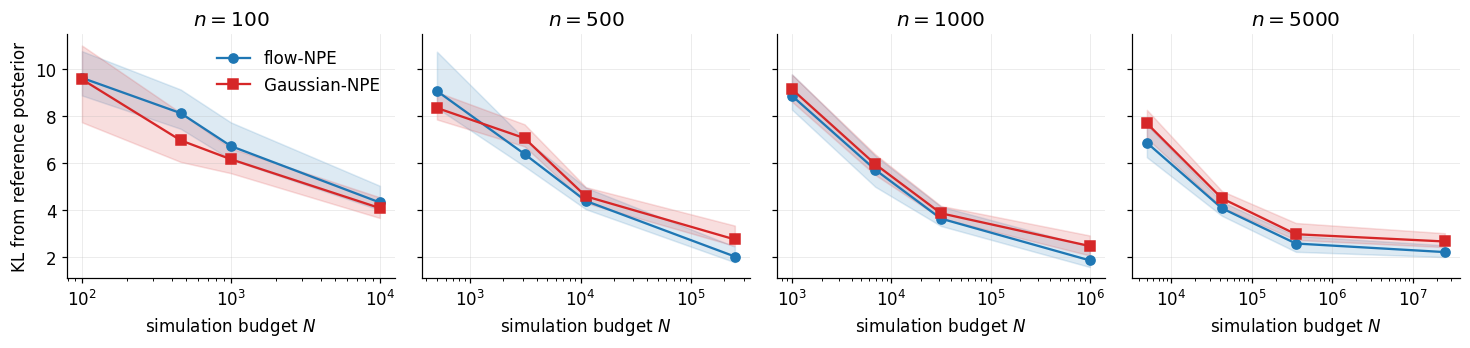

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.3), sharey=True)
for ax, n in zip(axes, N_OBS):
    sub = grid[grid.n == n].sort_values("N")
    ax.plot(sub.N, sub.flow_theta_kl_median, "o-", color=C_FLOW, label="flow-NPE")
    ax.fill_between(sub.N, sub.flow_theta_kl_q25, sub.flow_theta_kl_q75,
                    color=C_FLOW, alpha=0.15)
    ax.plot(sub.N, sub.gaussian_theta_kl_median, "s-", color=C_GAUSS,
            label="Gaussian-NPE")
    ax.fill_between(sub.N, sub.gaussian_theta_kl_q25, sub.gaussian_theta_kl_q75,
                    color=C_GAUSS, alpha=0.15)
    ax.set_xscale("log")
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel(r"simulation budget $N$")
axes[0].set_ylabel("KL from reference posterior")
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

**Octile versus hexadecile summaries (Gaussian-NPE).** The same g-and-k
experiment with 7 octile summaries ($d_s = 7$) and 15 hexadecile summaries
($d_s = 15$), for the two sample sizes where the hexadecile runs exist. The
hexadecile KL sits above the octile KL, a larger summary dimension needs a
larger budget $N$ for the same accuracy. This isolates the dimension effect
directly, since only $d_s$ changes.

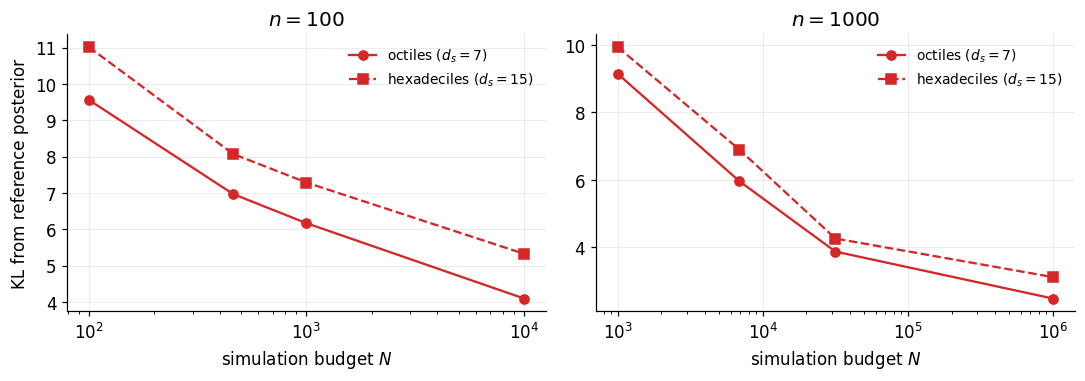

In [7]:
oct_df = grid
hex_g = pd.read_csv(DATA / "gnk_hexadecile_gaussian.csv")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, n in zip(axes, [100, 1000]):
    o = oct_df[oct_df.n == n].sort_values("N")
    ax.plot(o.N, o.gaussian_theta_kl_median, "o-", color=C_GAUSS,
            label=r"octiles ($d_s=7$)")
    h = hex_g[hex_g.n_obs == n].sort_values("n_sims")
    ax.plot(h.n_sims, h.finite_kl_median, "s--", color=C_GAUSS,
            label=r"hexadeciles ($d_s=15$)")
    ax.set_xscale("log")
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel(r"simulation budget $N$")
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("KL from reference posterior")
fig.tight_layout()
plt.show()

**Posterior overlay across the scaling grid.** Each row is one $(n, N)$ cell,
with $n$ and $N$ increasing down the rows, and the columns are the four
parameters. Dashed lines mark the true values. The $n=1000$ rows use seed 36 and
the $n=5000$ rows use seed 50.

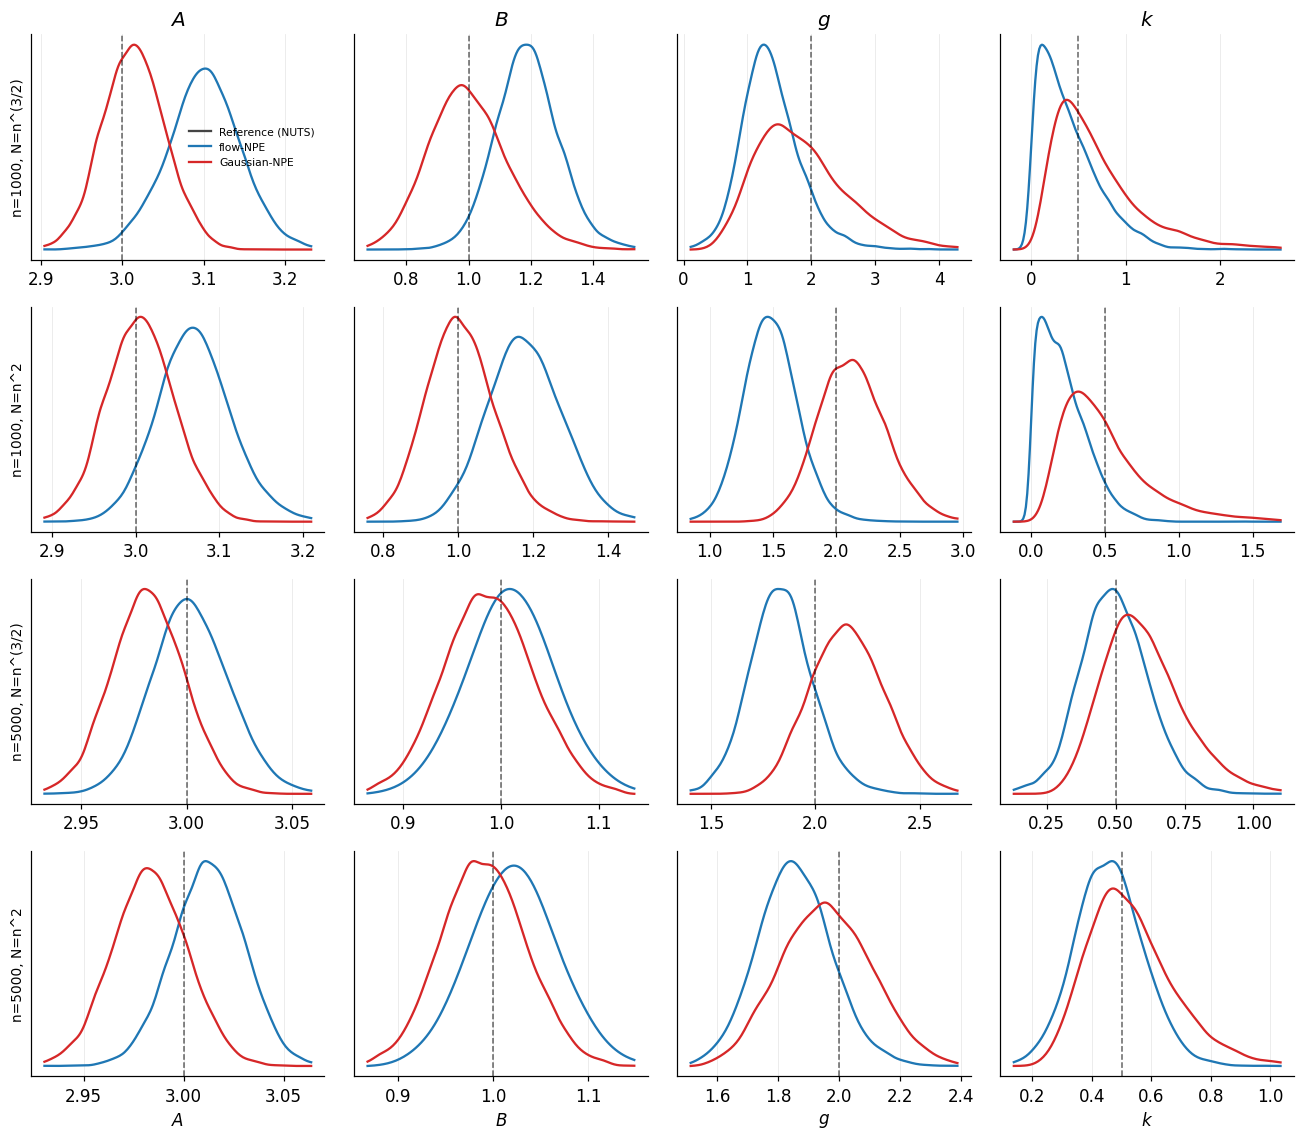

In [8]:
gnk_ov = pd.read_csv(DATA / "gnk_posterior_overlay.csv")
cells = ["n=1000, N=n^(3/2)", "n=1000, N=n^2",
         "n=5000, N=n^(3/2)", "n=5000, N=n^2"]
gnk_params = ["A", "B", "g", "k"]
overlay = [("Reference (NUTS)", C_REF), ("flow-NPE", C_FLOW),
           ("Gaussian-NPE", C_GAUSS)]
fig, axes = plt.subplots(4, 4, figsize=(12, 10.5))
for i, cell in enumerate(cells):
    for j, param in enumerate(gnk_params):
        ax = axes[i, j]
        for method, color in overlay:
            s = gnk_ov[(gnk_ov.cell == cell) & (gnk_ov.method == method)
                       & (gnk_ov.param == param)].sort_values("x")
            ax.plot(s.x, s.density, color=color, label=method)
        ax.axvline(GNK_TRUE[param], color="black", ls="--", lw=1, alpha=0.6)
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f"${PARAM_MATH[param]}$")
        if i == 3:
            ax.set_xlabel(f"${PARAM_MATH[param]}$")
        if j == 0:
            ax.set_ylabel(cell, fontsize=9)
axes[0, 0].legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

flow-NPE and Gaussian-NPE give very similar KL across the grid, and both fall
as the budget grows, in line with the target being close to Gaussian here. The
overlay shows both fitted posteriors moving onto the NUTS reference as $n$ and
$N$ increase, with the largest gap on the shape parameters $g$ and $k$ at the
smaller budgets. A residual gap remains even at $N = n^2$, which reads as
finite-N approximation error rather than a limitation of the Gaussian family,
since the moment-matched Gaussian row shows the target is already very close to
Gaussian at the larger sample sizes.

# MA(2)

The MA(2) model has two parameters $(\theta_1, \theta_2)$ and three summaries,
so $d = 5$, the lowest of the three examples, and its summaries are
asymptotically Gaussian. This makes it the cleanest version of the theory's
nice case. It is shown in two parts, the compatible case where the model can
match the data, and a compatibility stress test where it cannot.

**Post-timeout status.** The paper-facing MA(2) compatibility figure currently
uses $n=1000$, not the attempted $n=5000,\ N=25M$ flow cell. The exact
compatible refresh at $\delta_0=1$ produced complete files for every
Gaussian-NPE row, while the largest flow-NPE cell timed out after producing only
setup artifacts and no metrics. The 25M flow row is therefore an operational
timeout, not a scientific KL value, and it is not needed for the current
paper-facing MA(2) claim. For Gaussian-NPE, finite KL medians and `Inf` KL
counts are reported separately; MMD stays finite across the completed rows.

In [9]:
delta1 = pd.read_csv(DATA / "ma2_delta1_refresh.csv")
delta1_audit = pd.read_csv(DATA / "ma2_delta1_refresh_audit.csv")
delta1["budget"] = pd.Categorical(delta1["budget_label"], categories=BUDGETS,
                                  ordered=True)

status_cols = [
    "status_complete_rows", "nonfinite_kl_status_rows", "missing_rows",
    "timed_out_rows", "partial_training_only_rows", "bad_shape_rows",
]
for col in status_cols:
    if col not in delta1.columns:
        delta1[col] = 0

status_overview = (
    delta1_audit.groupby(["method", "status"]).size()
    .unstack(fill_value=0)
    .reindex(["flow_npe", "gaussian_npe"])
)
status_overview.index = status_overview.index.map(METHOD_NAME)
status_overview

status,complete,nonfinite_kl,partial_training_only
method,,,
flow-NPE,1478,1,137
Gaussian-NPE,1493,123,0


**Compatible case.** Median KL from the NUTS reference posterior at the
true-data summaries, shown as flow-NPE / Gaussian-NPE, across $n$ and $N$.
Gaussian-NPE reaches a small KL and keeps falling as the budget grows. flow-NPE
does not, it stays roughly flat. The $n=5000,\ N=n^2$ compatible-case cell is
left blank and labelled as not completed.

In [10]:
ma2kl = pd.read_csv(DATA / "ma2_b0_kl.csv")
ma2kl = ma2kl.sort_values(["method", "n_obs", "n_sims"])
ma2kl["budget"] = ma2kl.groupby(["method", "n_obs"]).cumcount().map(
    dict(enumerate(BUDGETS)))
piv = ma2kl.pivot_table(index=["method", "budget"], columns="n_obs",
                        values="kl_median")
seed_piv = ma2kl.pivot_table(index=["method", "budget"], columns="n_obs",
                             values="n_seeds", aggfunc="max")
flow = piv.loc["flow_npe"].reindex(BUDGETS)
gauss = piv.loc["gaussian_npe"].reindex(BUDGETS)
flow_n = seed_piv.loc["flow_npe"].reindex(BUDGETS).fillna(0)
gauss_n = seed_piv.loc["gaussian_npe"].reindex(BUDGETS).fillna(0)

def _fmt(v, n):
    if pd.isna(v) or n == 0:
        return "not completed"
    return f"{v:.3f}"

ma2_compat = pd.DataFrame(
    {n: [f"{_fmt(flow.loc[b, n], flow_n.loc[b, n])} / "
         f"{_fmt(gauss.loc[b, n], gauss_n.loc[b, n])}"
         for b in BUDGETS]
     for n in flow.columns}, index=BUDGETS)
ma2_compat.index.name = "budget"
ma2_compat.columns.name = "n"
ma2_compat

n,100,500,1000,5000
budget,,,,
N=n,0.807 / 0.771,0.713 / 0.359,0.574 / 0.324,0.483 / 0.226
N=n log(n),0.619 / 0.460,0.521 / 0.238,0.409 / 0.181,0.443 / 0.111
N=n^(3/2),0.530 / 0.392,0.440 / 0.147,0.469 / 0.096,0.593 / 0.034
N=n^2,0.428 / 0.318,0.542 / 0.068,0.667 / 0.040,not completed / not completed


**Compatible case, KL versus budget.** The same medians as the table, drawn
against the budget $N$, one panel per $n$. Missing largest-budget values are
shown as labels rather than silently dropped.

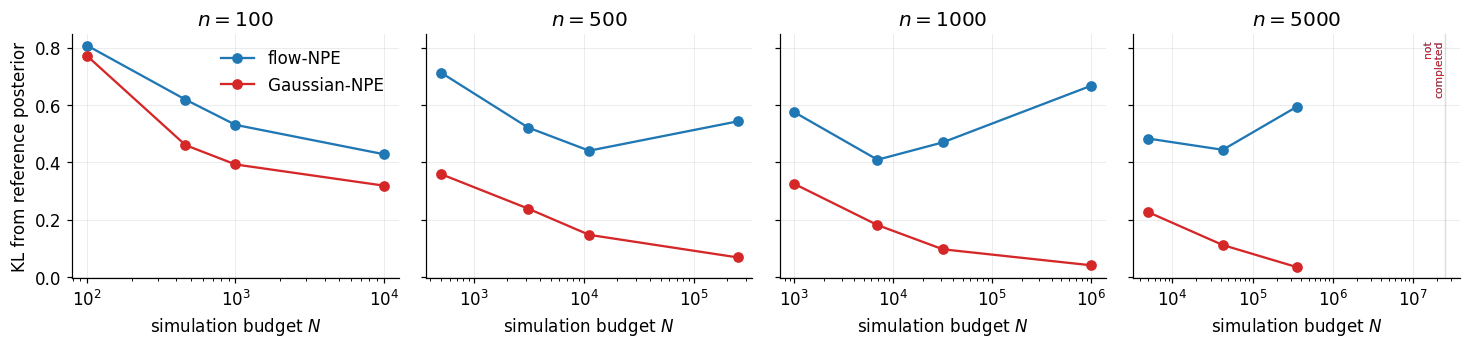

In [11]:
ma2kl_plot = pd.read_csv(DATA / "ma2_b0_kl.csv")
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.3), sharey=True)
for ax, n in zip(axes, N_OBS):
    for raw, color, mlabel in [("flow_npe", C_FLOW, "flow-NPE"),
                               ("gaussian_npe", C_GAUSS, "Gaussian-NPE")]:
        s = ma2kl_plot[(ma2kl_plot.method == raw) & (ma2kl_plot.n_obs == n)]
        s = s.sort_values("n_sims")
        done = s[(s.n_seeds > 0) & s.kl_median.notna()]
        ax.plot(done.n_sims, done.kl_median, "o-", color=color, label=mlabel)
        missing = s[(s.n_seeds == 0) | s.kl_median.isna()]
        for _, row in missing.iterrows():
            ax.axvline(row.n_sims, color="#dddddd", linewidth=0.8, zorder=0)
            ax.text(row.n_sims, 0.98, "not\ncompleted", color=color, fontsize=7,
                    rotation=90, va="top", ha="right",
                    transform=ax.get_xaxis_transform())
    ax.set_xscale("log")
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel(r"simulation budget $N$")
axes[0].set_ylabel("KL from reference posterior")
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

**Exact compatible refresh completion.** Each cell below is the number of
$\delta_0=1$ jobs with complete files and valid sample shapes out of 101
manifest seeds. `Inf` KL counts are labelled separately. The largest flow-NPE
cell has no metrics and is marked as partial training only because the job
reached setup/standardisation artifacts but timed out before producing
posterior samples, KL, or MMD.

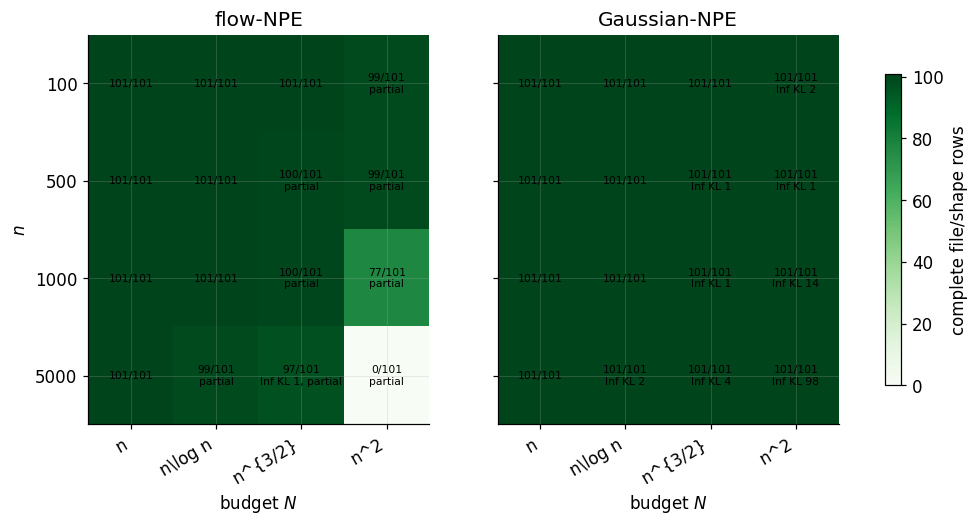

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, method in zip(axes, ["flow_npe", "gaussian_npe"]):
    s = delta1[delta1.method == method].copy()
    mat = s.pivot(index="n_obs", columns="budget", values="complete_rows")
    mat = mat.reindex(index=N_OBS, columns=BUDGETS).fillna(0)
    im = ax.imshow(mat.values, vmin=0, vmax=101, cmap="Greens", aspect="auto")
    ax.set_title(METHOD_NAME[method])
    ax.set_xticks(range(len(BUDGETS)), BUDGET_MATH, rotation=30, ha="right")
    ax.set_yticks(range(len(N_OBS)), [str(n) for n in N_OBS])
    ax.set_xlabel(r"budget $N$")
    if ax is axes[0]:
        ax.set_ylabel(r"$n$")
    for i, n in enumerate(N_OBS):
        for j, budget in enumerate(BUDGETS):
            row = s[(s.n_obs == n) & (s.budget_label == budget)]
            if row.empty:
                label = "0/101\nmissing"
            else:
                row = row.iloc[0]
                label = f"{int(row.complete_rows)}/101"
                extra = []
                if int(row.nonfinite_kl_status_rows):
                    extra.append(f"Inf KL {int(row.infinite_kl_rows)}")
                if int(row.partial_training_only_rows):
                    extra.append("partial")
                if int(row.timed_out_rows):
                    extra.append("timeout")
                if int(row.missing_rows):
                    extra.append(f"missing {int(row.missing_rows)}")
                if extra:
                    label += "\n" + ", ".join(extra[:2])
            ax.text(j, i, label, ha="center", va="center", fontsize=7,
                    color="black")
fig.colorbar(im, ax=axes, shrink=0.8, label="complete file/shape rows")
plt.show()

**Exact compatible refresh, KL and MMD versus budget.** This uses the
$\delta_0=1$ refresh outputs. Cells with no finite KL or MMD are explicitly
marked at their budget position.

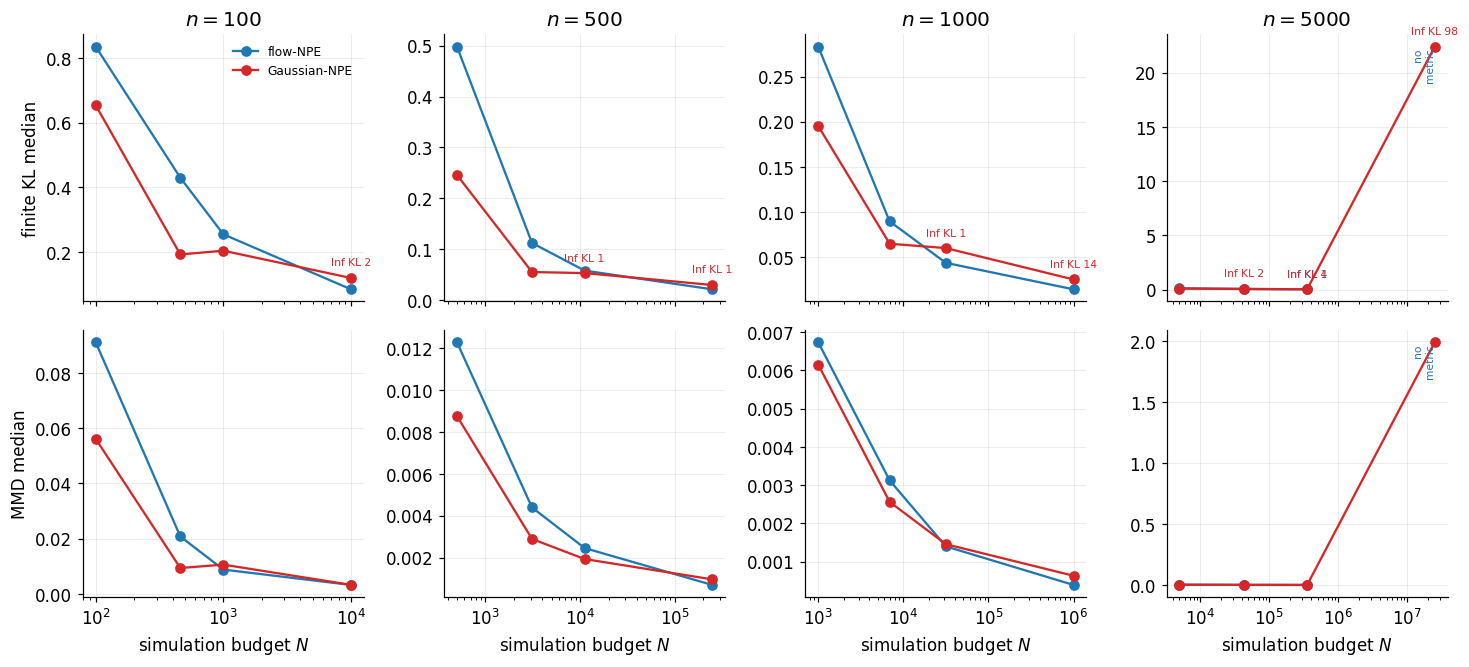

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.2), sharex="col")
for col, n in enumerate(N_OBS):
    for method, color, label in [("flow_npe", C_FLOW, "flow-NPE"),
                                 ("gaussian_npe", C_GAUSS, "Gaussian-NPE")]:
        s = delta1[(delta1.method == method) & (delta1.n_obs == n)].sort_values("n_sims")
        kl_done = s[(s.finite_kl_rows > 0) & s.finite_kl_median.notna()]
        mmd_done = s[(s.finite_mmd_rows > 0) & s.mmd_median.notna()]
        axes[0, col].plot(kl_done.n_sims, kl_done.finite_kl_median, "o-",
                          color=color, label=label)
        axes[1, col].plot(mmd_done.n_sims, mmd_done.mmd_median, "o-",
                          color=color, label=label)
        missing = s[s.finite_kl_rows == 0]
        for _, row in missing.iterrows():
            axes[0, col].text(row.n_sims, 0.95, "no\nmetric", color=color,
                              fontsize=7, rotation=90, va="top", ha="right",
                              transform=axes[0, col].get_xaxis_transform())
            axes[1, col].text(row.n_sims, 0.95, "no\nmetric", color=color,
                              fontsize=7, rotation=90, va="top", ha="right",
                              transform=axes[1, col].get_xaxis_transform())
        inf_kl = s[s.infinite_kl_rows > 0]
        for _, row in inf_kl.iterrows():
            axes[0, col].annotate(f"Inf KL {int(row.infinite_kl_rows)}",
                                  xy=(row.n_sims, row.finite_kl_median),
                                  xytext=(0, 8), textcoords="offset points",
                                  color=color, fontsize=7, ha="center")
    axes[0, col].set_title(f"$n = {n}$")
    axes[1, col].set_xlabel(r"simulation budget $N$")
    for row in range(2):
        axes[row, col].set_xscale("log")
axes[0, 0].set_ylabel("finite KL median")
axes[1, 0].set_ylabel("MMD median")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

**Compatibility stress test.** The observed summary is set to an incompatible
value. $\delta_0=0.99$ is a minor incompatibility, $\delta_0=0.01$ is a major
one, and $\delta_0=1$ is the exact compatible anchor. The tables separate
finite-KL medians from infinite-KL counts, because the most incompatible cells
can produce valid MMD while KL is infinite for some seeds.

In [14]:
ma2_base = pd.read_csv(DATA / "ma2_compatibility.csv").copy()
ma2_base["method"] = "gaussian_npe"
ma2_delta1_gauss = delta1[(delta1.method == "gaussian_npe") &
                          (delta1.n_obs == 1000)].copy()
ma2_stress = pd.concat([ma2_base, ma2_delta1_gauss], ignore_index=True, sort=False)
ma2_stress["budget"] = pd.Categorical(ma2_stress["budget_label"],
                                      categories=BUDGETS, ordered=True)
ma2_stress = ma2_stress.sort_values(["delta0", "budget"])

def stress_pivot(value, digits=4):
    t = ma2_stress.pivot_table(index="budget", columns="delta0", values=value,
                               observed=True)
    t = t.reindex(BUDGETS)
    return t.rename_axis(index="budget", columns="delta0").round(digits)

print("Finite KL median, Gaussian-NPE at n=1000")
stress_pivot("finite_kl_median")

Finite KL median, Gaussian-NPE at n=1000


delta0,0.01,0.99,1.00
budget,,,
N=n,11.2205,0.2595,0.1953
N=n log(n),11.3578,0.0618,0.0647
N=n^(3/2),11.2632,0.0508,0.0599
N=n^2,10.8380,0.0307,0.0251


In [15]:
print("Infinite KL rows out of 101, Gaussian-NPE at n=1000")
stress_pivot("infinite_kl_rows", digits=0).astype("Int64")

Infinite KL rows out of 101, Gaussian-NPE at n=1000


delta0,0.01,0.99,1.00
budget,,,
N=n,0,0,0
N=n log(n),0,0,0
N=n^(3/2),1,0,1
N=n^2,15,14,14


In [16]:
print("MMD median, Gaussian-NPE at n=1000")
stress_pivot("mmd_median")

MMD median, Gaussian-NPE at n=1000


delta0,0.01,0.99,1.00
budget,,,
N=n,1.0062,0.0064,0.0062
N=n log(n),1.0478,0.0027,0.0026
N=n^(3/2),1.0309,0.0018,0.0015
N=n^2,0.9627,0.0006,0.0006


**KL and MMD versus budget** for the Gaussian-NPE stress-test curve and exact
compatible anchor.

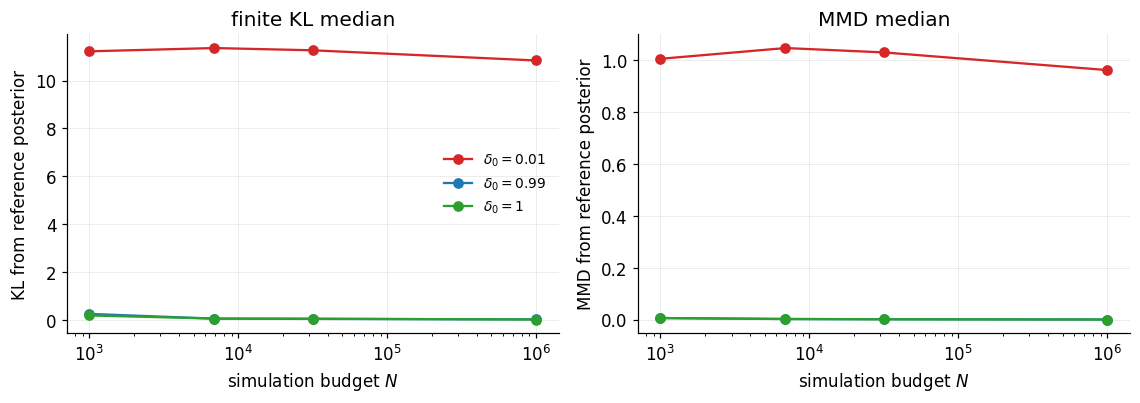

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
series = [(0.01, C_GAUSS, r"$\delta_0 = 0.01$"),
          (0.99, C_FLOW, r"$\delta_0 = 0.99$"),
          (1.00, C_DELTA1, r"$\delta_0 = 1$")]
for d0, color, label in series:
    s = ma2_stress[np.isclose(ma2_stress.delta0, d0)].sort_values("n_sims")
    axes[0].plot(s.n_sims, s.finite_kl_median, "o-", color=color, label=label)
    axes[1].plot(s.n_sims, s.mmd_median, "o-", color=color, label=label)
axes[0].set_title("finite KL median")
axes[0].set_ylabel("KL from reference posterior")
axes[1].set_title("MMD median")
axes[1].set_ylabel("MMD from reference posterior")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel(r"simulation budget $N$")
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

The refreshed $\delta_0=1$ anchor confirms that Gaussian-NPE is computationally
complete on the exact compatible MA(2) target, including the
$n=5000,\ N=25M$ cell, but the largest cell has many `Inf` KL estimates and is
best read through both finite-KL medians and all-finite MMD. The failed
largest-budget flow-NPE row is not evidence about posterior accuracy; it is
evidence that this runner/resource request is too expensive for that cell. For
the current paper, the MA(2) claim can stay focused on the $n=1000$
compatibility and incompatibility curves: Gaussian-NPE is good at
$\delta_0=1$ and under minor incompatibility, while the major incompatibility
keeps KL large even as $N$ grows.

# Where to go from here

The meeting is short, about 30 minutes, and David Frazier is away until later
in the month. The aim is to settle the points below that do not need him, and
to leave with the paper-framing questions sharp enough to send him by email.

- Scope of the remaining experiments, the main decision for this meeting.
  Updating the previous experiments to include Gaussian-NPE is close to done.
  The question is whether that is enough for the next iteration of the paper,
  or whether a larger effort is wanted within the remaining RA time. The two
  candidates for a larger effort are a dimension-scaling experiment (next
  point) and a Bayesian synthetic likelihood (BSL) run as an extra reference,
  since BSL uses model simulations rather than an asymptotic argument.
- The $d^2 n$ scaling. The theory says the budget must grow with the dimension,
  $N \gg d^2 n$. The current results show this only indirectly, the
  higher-dimensional g-and-k example needs a larger budget than the
  lower-dimensional stereological one. An experiment that varied the summary
  dimension over several values at a fixed $n$, and tracked the budget needed
  for a fixed accuracy, would test the $d^2$ scaling directly. This is partly a
  David Frazier point, worth confirming the framing with him.
- Reproducibility and handoff. The data has been archived to Zenodo so it can
  be linked from the paper. A start has been made on reducing the run and
  figure pipeline to a single documented command, this still needs to be
  finished before the experiments are handed over. A smaller clean-up item, a
  longer SMC-ABC run would let the stereological overlay cover $\sigma$ and
  $\xi$, not just $\lambda$.
- For the fuller meeting with David Frazier. How to present Gaussian-NPE in the
  paper. It is not a new method, a conditional Gaussian is a standard density
  estimator, but framing it as the nice-case companion to the theory is new.
  The residual gap in the g-and-k example reads as finite-N approximation error
  rather than a Gaussian-family limitation.

# Summary

- The simulation budget $N$ has to grow with both the sample size $n$ and the
  dimension $d$. Across all three examples the KL from the reference falls as
  the budget grows for fixed $n$, and the budget needed for good coverage rises
  with $d$. The stereological example ($d = 7$) is fine by $n^{3/2}$ while the
  g-and-k example ($d = 11$) needs $n^2$.
- Once the target posterior is close to Gaussian, the simpler Gaussian-NPE is
  broadly comparable to flow-NPE, and on the cleanest nice case, the MA(2)
  compatible case, it is clearly better. This is the empirical face of the
  theory's nice case, where the approximating family only needs to contain
  Gaussians.
- A residual gap to the reference remains at feasible budgets, which reads as
  finite-N approximation error rather than a Gaussian-family limitation.